# GameScope — Data Exploration (PM2)

This notebook explores the curated GameScope dataset: **5,000 Steam games** with up to **25 top English reviews each**, selected via hybrid genre sampling for diversity.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load curated data
with open("data/curated_games.json", "r", encoding="utf-8") as f:
    games = json.load(f)

with open("data/curated_reviews.json", "r", encoding="utf-8") as f:
    reviews = json.load(f)

print(f"Games: {len(games)}")
print(f"Total reviews: {sum(len(v) for v in reviews.values()):,}")
print(f"Avg reviews/game: {sum(len(v) for v in reviews.values()) / len(games):.1f}")

Games: 5000
Total reviews: 120,397
Avg reviews/game: 24.1


## Dataset Overview

Our **full dataset** contains 65,686 games and ~31.8 million reviews (11 GB). For feasibility, we curated a subset using hybrid genre sampling:

- Filtered to games with review files, at least one genre, and 10+ positive reviews (16,929 eligible)
- Small genres (≤50 games): included all games for diversity
- Large genres: proportional allocation, prioritizing most popular games
- Reviews filtered to **English only** (≥90% ASCII, ≥20 chars), sorted by helpfulness

| Metric | Sample | Final |
|--------|--------|-------|
| Games | 5,000 | 5,000 |
| Reviews | ~120,000 | ~120,000 |
| Size | ~158 MB | ~158 MB |

## Plot 1: Distribution of Games by Primary Genre

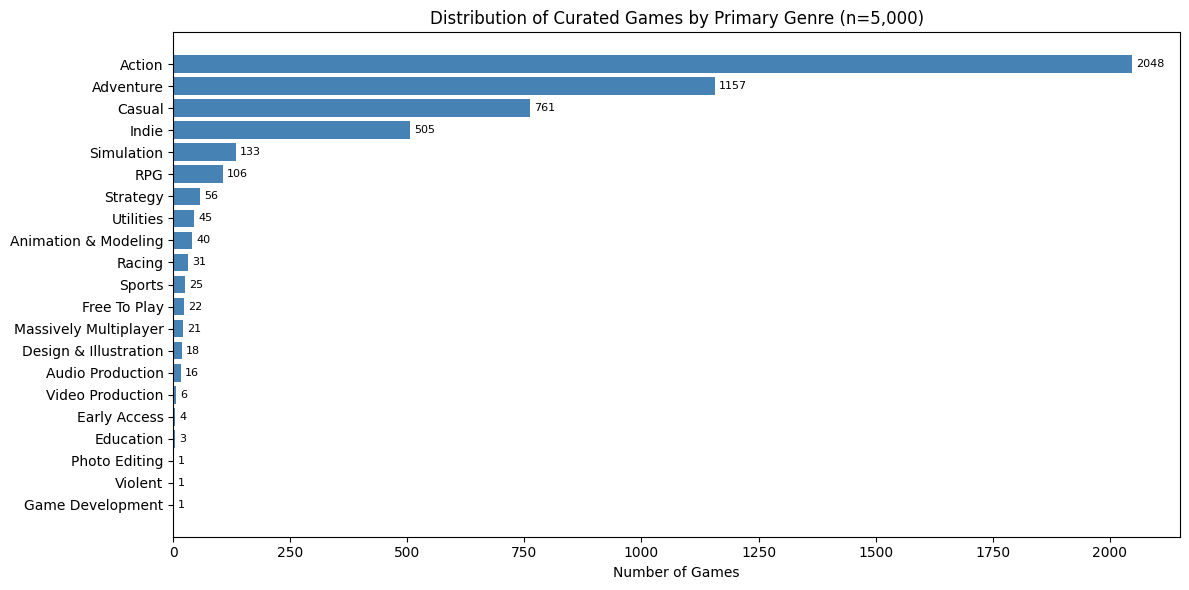


Total genres represented: 21
Largest genre: Action (2048 games)
Smallest genre(s): Early Access, Education, Photo Editing, Violent, Game Development


In [2]:
# Count games per primary genre
genre_counts = Counter()
for app_id, game in games.items():
    genre_counts[game["genres"][0]] += 1

# Sort by count
genres_sorted = genre_counts.most_common()
labels = [g for g, _ in genres_sorted]
counts = [c for _, c in genres_sorted]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(labels[::-1], counts[::-1], color="steelblue")
ax.set_xlabel("Number of Games")
ax.set_title("Distribution of Curated Games by Primary Genre (n=5,000)")
ax.bar_label(bars, padding=3, fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nTotal genres represented: {len(genre_counts)}")
print(f"Largest genre: {labels[0]} ({counts[0]} games)")
print(f"Smallest genre(s): {', '.join(g for g, c in genres_sorted if c <= 5)}")

## Plot 2: Review Length Distribution

Review length matters for our search engine — longer reviews contain richer experiential language for matching user queries.

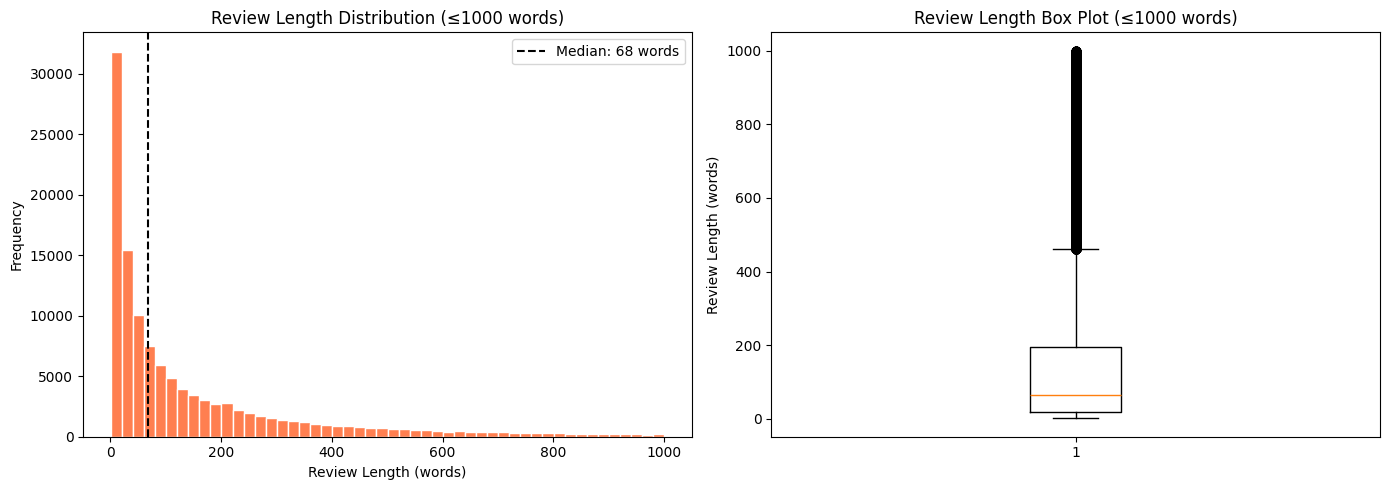

Total reviews: 120,397
Mean length: 174 words
Median length: 68 words
Min: 1 words | Max: 2,182 words
Reviews > 100 words: 49,661 (41.2%)


In [3]:
# Compute review lengths (word count)
review_lengths = []
for app_id, revs in reviews.items():
    for r in revs:
        review_lengths.append(len(r["review"].split()))

review_lengths = np.array(review_lengths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (clipped at 1000 words for readability)
axes[0].hist(review_lengths[review_lengths <= 1000], bins=50, color="coral", edgecolor="white")
axes[0].set_xlabel("Review Length (words)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Review Length Distribution (≤1000 words)")
axes[0].axvline(np.median(review_lengths), color="black", linestyle="--", label=f"Median: {int(np.median(review_lengths))} words")
axes[0].legend()

# Box plot
axes[1].boxplot(review_lengths[review_lengths <= 1000], vert=True)
axes[1].set_ylabel("Review Length (words)")
axes[1].set_title("Review Length Box Plot (≤1000 words)")

plt.tight_layout()
plt.show()

print(f"Total reviews: {len(review_lengths):,}")
print(f"Mean length: {np.mean(review_lengths):.0f} words")
print(f"Median length: {np.median(review_lengths):.0f} words")
print(f"Min: {np.min(review_lengths)} words | Max: {np.max(review_lengths):,} words")
print(f"Reviews > 100 words: {np.sum(review_lengths > 100):,} ({np.mean(review_lengths > 100)*100:.1f}%)")

## Plot 3: Review Helpfulness Distribution

We selected reviews by helpfulness (community upvotes). This shows the quality signal in our curated reviews.

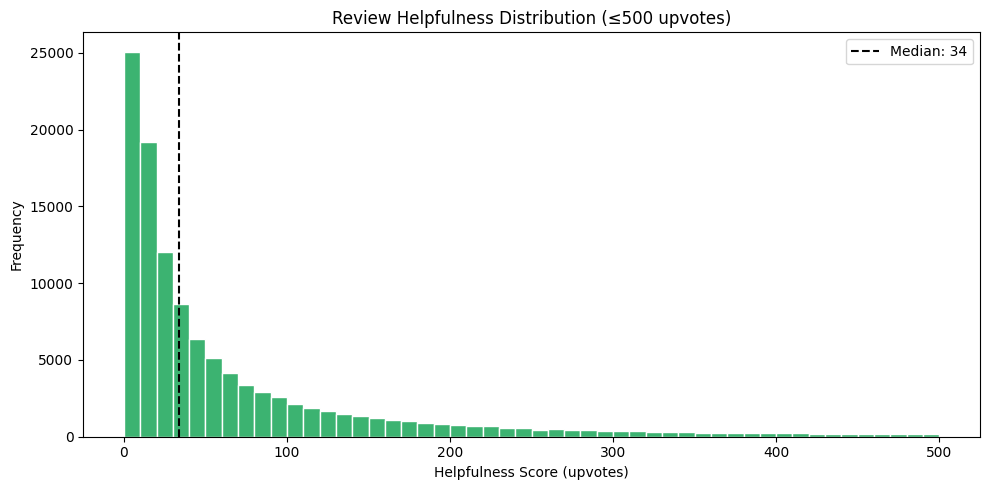

Mean helpfulness: 147.1
Median helpfulness: 34
Max helpfulness: 38,451
Reviews with 0 helpfulness: 2,291 (1.9%)


In [4]:
# Helpfulness scores
helpfulness_scores = []
for app_id, revs in reviews.items():
    for r in revs:
        helpfulness_scores.append(r["helpfulness"])

helpfulness_scores = np.array(helpfulness_scores)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(helpfulness_scores[helpfulness_scores <= 500], bins=50, color="mediumseagreen", edgecolor="white")
ax.set_xlabel("Helpfulness Score (upvotes)")
ax.set_ylabel("Frequency")
ax.set_title("Review Helpfulness Distribution (≤500 upvotes)")
ax.axvline(np.median(helpfulness_scores), color="black", linestyle="--", label=f"Median: {int(np.median(helpfulness_scores))}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean helpfulness: {np.mean(helpfulness_scores):.1f}")
print(f"Median helpfulness: {np.median(helpfulness_scores):.0f}")
print(f"Max helpfulness: {np.max(helpfulness_scores):,}")
print(f"Reviews with 0 helpfulness: {np.sum(helpfulness_scores == 0):,} ({np.mean(helpfulness_scores == 0)*100:.1f}%)")

## Plot 4: Positive vs Negative Review Ratio by Genre

The sentiment ratio is a social signal we'll use to boost well-received games in search rankings.

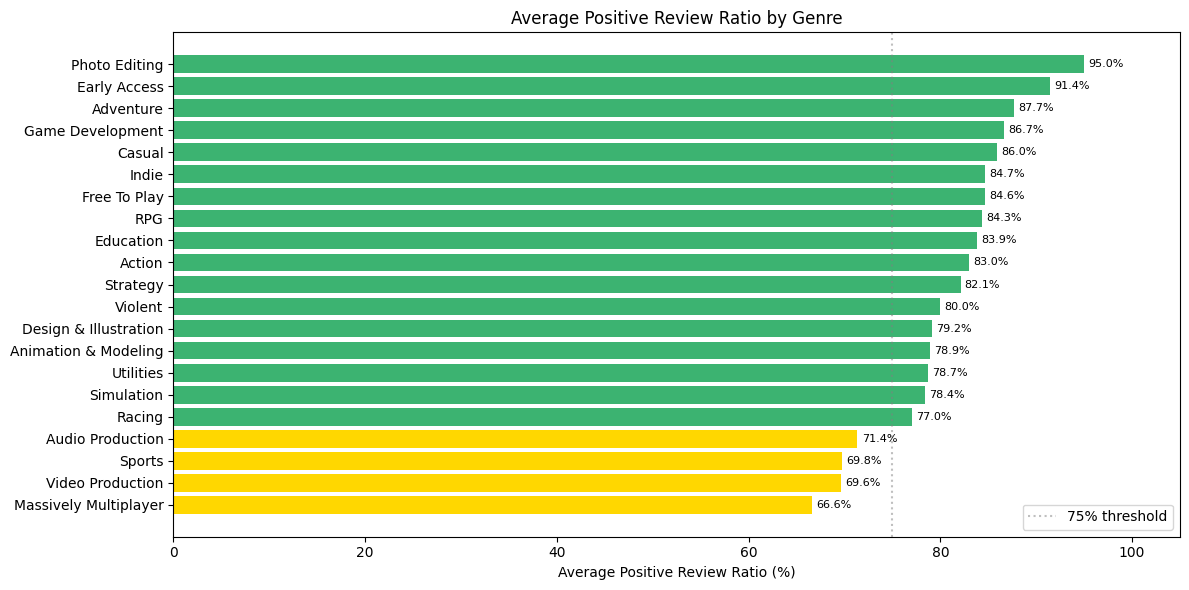

In [5]:
# Compute average positive ratio per genre
genre_ratios = {}
for app_id, game in games.items():
    genre = game["genres"][0]
    pos = game.get("positive", 0)
    neg = game.get("negative", 0)
    total = pos + neg
    if total > 0:
        ratio = pos / total
        if genre not in genre_ratios:
            genre_ratios[genre] = []
        genre_ratios[genre].append(ratio)

# Average ratio per genre, sorted
genre_avg = {g: np.mean(ratios) for g, ratios in genre_ratios.items()}
sorted_genres = sorted(genre_avg.items(), key=lambda x: x[1], reverse=True)
labels = [g for g, _ in sorted_genres]
avgs = [a for _, a in sorted_genres]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["mediumseagreen" if a >= 0.75 else "gold" if a >= 0.6 else "salmon" for a in avgs]
bars = ax.barh(labels[::-1], [a * 100 for a in avgs[::-1]], color=colors[::-1])
ax.set_xlabel("Average Positive Review Ratio (%)")
ax.set_title("Average Positive Review Ratio by Genre")
ax.axvline(75, color="gray", linestyle=":", alpha=0.5, label="75% threshold")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

## Sample Review Examples

A few examples showing the kind of experiential language our search engine will match against.

In [6]:
# Show 5 sample games with their top review snippet
import textwrap

sample_ids = list(games.keys())[:5]

for app_id in sample_ids:
    game = games[app_id]
    revs = reviews[app_id]
    print(f"{'='*80}")
    print(f"Game: {game['name']}")
    print(f"Genre: {', '.join(game.get('genres', []))}")
    print(f"Positive: {game.get('positive', 0):,} | Negative: {game.get('negative', 0):,}")
    if revs:
        top = revs[0]
        snippet = top["review"][:300] + ("..." if len(top["review"]) > 300 else "")
        print(f"Top review (helpfulness={top['helpfulness']}):")
        print(textwrap.fill(snippet, width=80, initial_indent="  ", subsequent_indent="  "))
    print()

Game: Live2DViewerEX
Genre: Animation & Modeling, Utilities
Positive: 3,128 | Negative: 251
Top review (helpfulness=179):
  Before I start off this review, I wanna give people an idea what this program
  is. Live2D Wallpaper is a program that allows you to apply live wallpapers to
  your desktop, very similar to Wallpaper Engine. The main difference with this
  program is that you have the ability to personalize the wallpaper ...

Game: Animaze by FaceRig
Genre: Animation & Modeling, Video Production
Positive: 2,096 | Negative: 978
Top review (helpfulness=468):
  Honestly I have mixed feelings about this. I love how the animations are
  better and have proven to be superior to facerig, but what I truly hate about
  this is that like most apps/buisness focused apps it uses a subscription based
  method for payment rather than paying for a full version directly. It'...

Game: YoloMouse - Game Cursor Changer
Genre: Animation & Modeling, Design & Illustration, Education, Software Training,

## Summary Statistics

In [7]:
# Summary statistics
total_reviews = sum(len(v) for v in reviews.values())
recommend_counts = Counter()
for revs in reviews.values():
    for r in revs:
        recommend_counts[r.get("recommend", "Unknown")] += 1

prices = [g.get("price", 0) for g in games.values() if g.get("price", 0) > 0]
playtimes = [g.get("average_playtime_forever", 0) for g in games.values() if g.get("average_playtime_forever", 0) > 0]

print("=== Dataset Summary ===")
print(f"Total games: {len(games):,}")
print(f"Total reviews: {total_reviews:,}")
print(f"Genres covered: {len(genre_counts)}")
print()
print("=== Review Sentiment ===")
for label, count in recommend_counts.most_common():
    print(f"  {label}: {count:,} ({count/total_reviews*100:.1f}%)")
print()
print("=== Game Pricing ===")
print(f"  Free games: {sum(1 for g in games.values() if g.get('price', 0) == 0):,}")
print(f"  Paid games median price: ${np.median(prices):.2f}")
print(f"  Paid games mean price: ${np.mean(prices):.2f}")
print()
print("=== Playtime (hours, among games with data) ===")
print(f"  Mean: {np.mean(playtimes):.0f} hrs")
print(f"  Median: {np.median(playtimes):.0f} hrs")
print()
print("=== Anticipated Challenges ===")
print("1. Full review corpus is 11 GB — we solved this by curating to 5K games with top reviews")
print("2. Non-English reviews filtered out; some games have <25 English reviews")
print("3. Review text is noisy (slang, memes, short jokes) — will need robust text preprocessing")
print("4. Highly skewed genre distribution — addressed with hybrid sampling strategy")

=== Dataset Summary ===
Total games: 5,000
Total reviews: 120,397
Genres covered: 21

=== Review Sentiment ===
  Recommended: 84,125 (69.9%)
  Not Recommended: 36,272 (30.1%)

=== Game Pricing ===
  Free games: 447
  Paid games median price: $14.99
  Paid games mean price: $18.13

=== Playtime (hours, among games with data) ===
  Mean: 874 hrs
  Median: 313 hrs

=== Anticipated Challenges ===
1. Full review corpus is 11 GB — we solved this by curating to 5K games with top reviews
2. Non-English reviews filtered out; some games have <25 English reviews
3. Review text is noisy (slang, memes, short jokes) — will need robust text preprocessing
4. Highly skewed genre distribution — addressed with hybrid sampling strategy
